In [57]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from glob import glob
import os

RESULTS_PATH_PATTERN = "/work/nvme/bbjs/sbharadwaj/powsm/PhoneBench/exp/rq1/*.csv"
DATASET = "timit"
# DATASET = "buckeye"

files = glob(RESULTS_PATH_PATTERN)
print(f"Found {len(files)} result files.")


def break_filename(fname):
    # return dataset, noise, filepath
    dataset = "timit"
    noise = fname[-5]
    if "buckeye_" in fname:
        dataset = "buckeye"

    return dataset, noise, fname


meta_and_file = [break_filename(f) for f in files]
# Read data from CSVs
dfs = [pd.read_csv(f) for f in files]
df = pd.concat(dfs, ignore_index=True)
df["dataset"] = [meta[0] for meta in meta_and_file]
df["noise"] = [int(meta[1]) * 10 for meta in meta_and_file]
df["file"] = [meta[2] for meta in meta_and_file]
df.rename(columns=lambda x: x.split()[0], inplace=True)
# Columns: dataset, eval_name, dataset, noise, FER, PER, PFER, N, Total Phones, FED, SUB, INS, DEL
# NOT FER (%),PER (%),SUB (%),INS (%),DEL (%)
# print(df.head())

# filter by dataset
print("Shape before filtering:", df.shape)
df = df[df["dataset"] == DATASET]
print("Shape after filtering:", df.shape)

# Extract model names (assuming eval_name contains the model info)
df["Model"] = df["eval_name"].str.split("/").str[-1]
for m in df.Model.unique():
    nm = m
    if "wav2vec2-large-xlsr-japlmthufielta" in m:
        nm = "MultiIPA"
    elif "wav2vec2-lv-60-espeak" in m:
        nm = "W2V2P-lv-60-ft"
    elif "wav2vec2-xlsr-53-espeak" in m:
        nm = "W2V2P-xlsr-53-ft"
    elif "zipa-large-crctc-500k" in m:
        nm = "Zipa-CRCTC"
    elif "zipa-large-crctc-ns-800k" in m:
        nm = "Zipa-CRCTC-ns"
    elif "powsm" in m:
        nm = "POWSM"
    df.loc[df.Model == m, "Model"] = nm

df = df.sort_values(by=["Model", "noise"])
print(df.Model.unique())

# Color and marker settings
colors = {
    "MultiIPA": "#e74c3c",
    "W2V2P-lv-60-ft": "#3498db",
    "W2V2P-xlsr-53-ft": "#2ecc71",
    "Zipa-CRCTC": "#9b59b6",
    "Zipa-CRCTC-ns": "#f1c40f",
    "POWSM": "#34495e",
}
markers = {
    "MultiIPA": "o",
    "W2V2P-lv-60-ft": "s",
    "W2V2P-xlsr-53-ft": "^",
    "Zipa-CRCTC": "D",
    "Zipa-CRCTC-ns": "v",
    "POWSM": "X",
}

Found 88 result files.
Shape before filtering: (88, 13)
Shape after filtering: (57, 13)
['MultiIPA' 'POWSM' 'W2V2P-lv-60-ft' 'W2V2P-xlsr-53-ft' 'Zipa-CRCTC'
 'Zipa-CRCTC-ns']


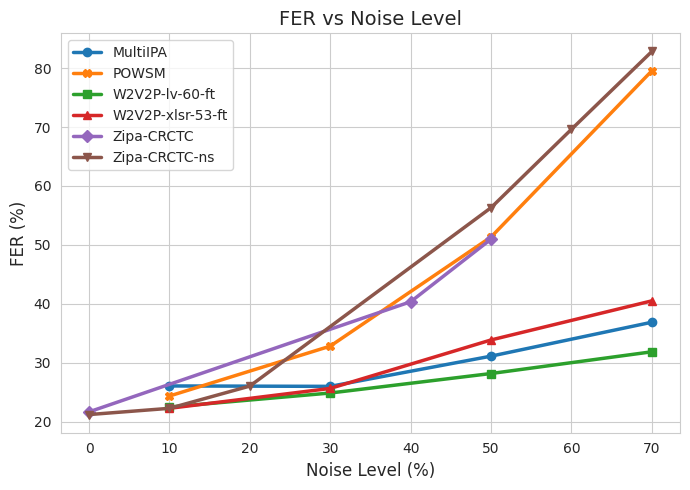

In [ ]:
import seaborn as sns


def plot_multigraph(df, plot_col="FER"):
    """
    df columns:
        Model : str
        noise : numeric
        FER   : numeric
    Uses model-specific markers defined in `markers` dict.
    """
    plt.figure(figsize=(7, 5))
    sns.set_style("whitegrid")

    # Draw one lineplot per model so we can control markers individually
    for model in df["Model"].unique():
        sub = df[df["Model"] == model]
        plt.plot(
            sub["noise"],
            sub[plot_col],
            label=model,
            marker=markers.get(model, "o"),
            linewidth=2.5,
        )

    plt.xlabel("Noise Level (%)", fontsize=12)
    plt.ylabel(f"{plot_col} (%)", fontsize=12)
    plt.title(f"{plot_col} vs Noise Level", fontsize=14)
    plt.legend()
    plt.tight_layout()
    plt.show()


# df = df[df.noise < 100]
plot_multigraph(df[df.noise < 80], plot_col="FER")

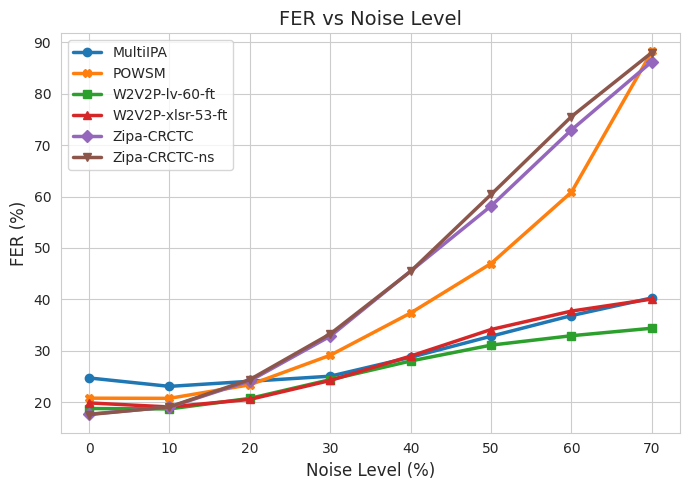

In [58]:
plot_multigraph(df[df.noise < 80], plot_col="FER")

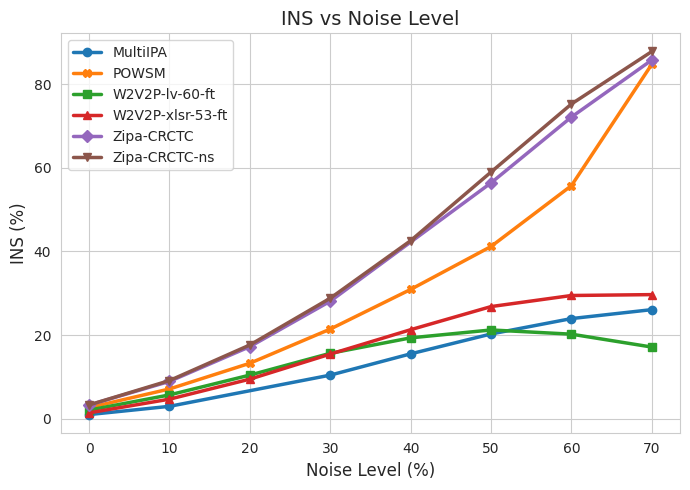

In [64]:
plot_multigraph(df[df.noise < 80], plot_col="INS")

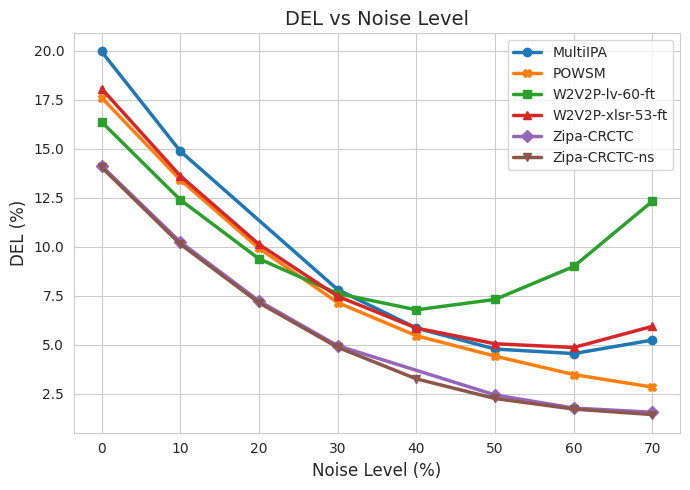

In [65]:
plot_multigraph(df[df.noise < 80], plot_col="DEL")

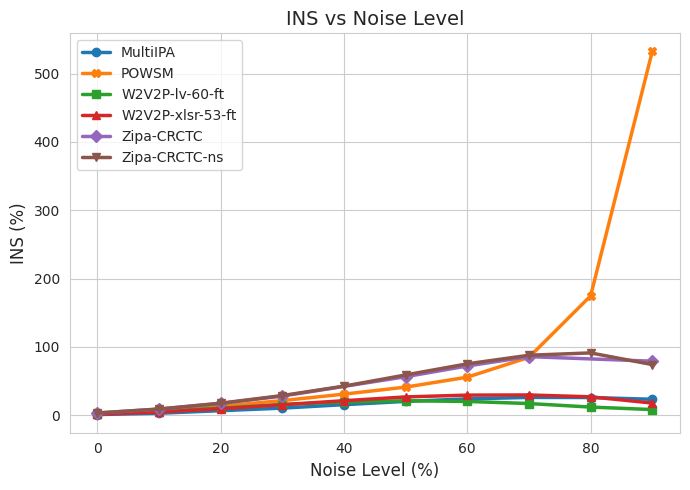

In [ ]:
plot_multigraph(df[df.noise < 100], plot_col="INS")